In [1]:
# =====================================================
# PHASE 2: ViT-B/16 TRAINING
# =====================================================

import os
import random
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F

C:\Users\harsh\anaconda3\envs\minor_project_env\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
# ===============================
# 1️⃣ REPRODUCIBILITY
# ===============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [3]:
# ===============================
# 2️⃣ CONFIG (PHASE 2)
# ===============================
DATA_ROOT = r"D:\Datasets\Phase2_224x224_HighPass"
MODEL_SAVE_PATH = r"D:\MinorProject\MinorProject6thSem\models\best_vitb16_highpass_phase2.pth"

BATCH_SIZE = 8
NUM_EPOCHS = 15
LR = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
# ===============================
# 3️⃣ TRANSFORMS
# ===============================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
# ===============================
# 4️⃣ DATASETS
# ===============================
train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"), transform=test_transform)
test_seen_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "test_seen"), transform=test_transform)
test_unseen_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "test_unseen"), transform=test_transform)

print("Class mapping:", train_dataset.class_to_idx)

Class mapping: {'fake': 0, 'real': 1}


In [6]:
# ===============================
# 5️⃣ DATALOADERS
# ===============================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_seen_loader = DataLoader(test_seen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_unseen_loader = DataLoader(test_unseen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [7]:
# ===============================
# 6️⃣ MODEL (ViT-B/16)
# ===============================
weights = models.ViT_B_16_Weights.DEFAULT
model = models.vit_b_16(weights=weights)

in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, 2)

model = model.to(DEVICE)

In [8]:
# ===============================
# 🔢 PARAMETER COUNT
# ===============================
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(model)

print("\n===== MODEL PARAMETERS =====")
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")


===== MODEL PARAMETERS =====
Total Parameters:     85,800,194
Trainable Parameters: 85,800,194


In [9]:
# ===============================
# 7️⃣ LOSS, OPTIMIZER, SCHEDULER
# ===============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [10]:
# ===============================
# 8️⃣ EVALUATION FUNCTION
# ===============================
def evaluate(model, loader, return_preds=False, return_probs=False):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            probs = F.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if return_preds:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            if return_probs:
                all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    if return_preds and return_probs:
        return avg_loss, accuracy, all_preds, all_labels, all_probs
    if return_preds:
        return avg_loss, accuracy, all_preds, all_labels

    return avg_loss, accuracy

In [11]:
# ===============================
# 9️⃣ TRAINING LOOP
# ===============================
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    scheduler.step()

    train_loss = running_loss / total
    train_acc = running_corrects / total
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())


Epoch [1/15]
Train Loss: 0.7043 | Train Acc: 0.4960
Val Loss:   0.6945 | Val Acc:   0.5000

Epoch [2/15]
Train Loss: 0.7039 | Train Acc: 0.5028
Val Loss:   0.6933 | Val Acc:   0.5000

Epoch [3/15]
Train Loss: 0.6984 | Train Acc: 0.4953
Val Loss:   0.6972 | Val Acc:   0.5000

Epoch [4/15]
Train Loss: 0.6976 | Train Acc: 0.4923
Val Loss:   0.6999 | Val Acc:   0.5000

Epoch [5/15]
Train Loss: 0.6968 | Train Acc: 0.4980
Val Loss:   0.6938 | Val Acc:   0.5000

Epoch [6/15]
Train Loss: 0.6934 | Train Acc: 0.5028
Val Loss:   0.6935 | Val Acc:   0.5000

Epoch [7/15]
Train Loss: 0.6935 | Train Acc: 0.4995
Val Loss:   0.6933 | Val Acc:   0.5000

Epoch [8/15]
Train Loss: 0.6936 | Train Acc: 0.5009
Val Loss:   0.6932 | Val Acc:   0.5000

Epoch [9/15]
Train Loss: 0.6934 | Train Acc: 0.5010
Val Loss:   0.6934 | Val Acc:   0.5000

Epoch [10/15]
Train Loss: 0.6934 | Train Acc: 0.4991
Val Loss:   0.6938 | Val Acc:   0.5000

Epoch [11/15]
Train Loss: 0.6935 | Train Acc: 0.5000
Val Loss:   0.6932 | Val 

In [12]:
# ===============================
# 🔟 SAVE BEST MODEL
# ===============================
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print("\nBest model saved locally.")


Best model saved locally.


In [13]:
# ===============================
# 1️⃣1️⃣ FINAL EVALUATION
# ===============================
train_loss, train_acc = evaluate(model, train_loader)
val_loss, val_acc = evaluate(model, val_loader)

test_seen_loss, test_seen_acc, seen_preds, seen_labels = evaluate(
    model, test_seen_loader, return_preds=True
)

test_unseen_loss, test_unseen_acc, unseen_preds, unseen_labels, unseen_probs = evaluate(
    model, test_unseen_loader, return_preds=True, return_probs=True
)

fpr, tpr, thresholds = roc_curve(unseen_labels, unseen_probs)
roc_auc = auc(fpr, tpr)

In [14]:
print("\n===== FINAL RESULTS =====")
print(f"Train Loss:       {train_loss:.4f} | Train Acc:       {train_acc:.4f}")
print(f"Validation Loss:  {val_loss:.4f} | Validation Acc:  {val_acc:.4f}")
print(f"Test Seen Loss:   {test_seen_loss:.4f} | Test Seen Acc:   {test_seen_acc:.4f}")
print(f"Test Unseen Loss: {test_unseen_loss:.4f} | Test Unseen Acc: {test_unseen_acc:.4f}")
print(f"Test Unseen AUC:  {roc_auc:.4f}")


===== FINAL RESULTS =====
Train Loss:       0.6945 | Train Acc:       0.5000
Validation Loss:  0.6945 | Validation Acc:  0.5000
Test Seen Loss:   0.6945 | Test Seen Acc:   0.5000
Test Unseen Loss: 0.6770 | Test Unseen Acc: 0.6667
Test Unseen AUC:  0.2580


In [15]:
print("\nConfusion Matrix - Test Seen")
print(confusion_matrix(seen_labels, seen_preds))
print(classification_report(seen_labels, seen_preds))


Confusion Matrix - Test Seen
[[500   0]
 [500   0]]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       500
           1       0.00      0.00      0.00       500

    accuracy                           0.50      1000
   macro avg       0.25      0.50      0.33      1000
weighted avg       0.25      0.50      0.33      1000



C:\Users\harsh\anaconda3\envs\minor_project_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\harsh\anaconda3\envs\minor_project_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\harsh\anaconda3\envs\minor_project_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [16]:
print("\nConfusion Matrix - Test Unseen")
print(confusion_matrix(unseen_labels, unseen_preds))
print(classification_report(unseen_labels, unseen_preds))


Confusion Matrix - Test Unseen
[[1000    0]
 [ 500    0]]
              precision    recall  f1-score   support

           0       0.67      1.00      0.80      1000
           1       0.00      0.00      0.00       500

    accuracy                           0.67      1500
   macro avg       0.33      0.50      0.40      1500
weighted avg       0.44      0.67      0.53      1500



C:\Users\harsh\anaconda3\envs\minor_project_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\harsh\anaconda3\envs\minor_project_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\harsh\anaconda3\envs\minor_project_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

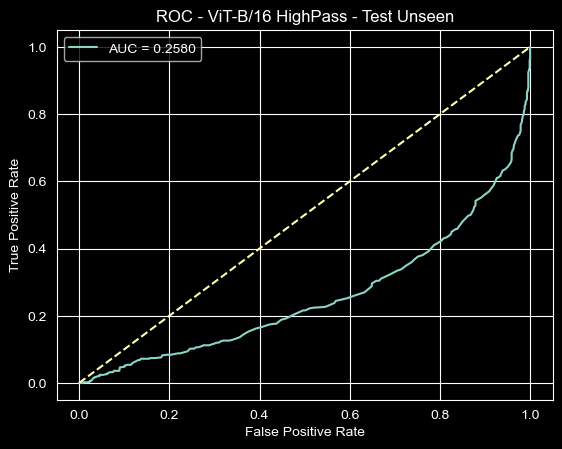

In [17]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - ViT-B/16 HighPass - Test Unseen")
plt.legend()
plt.show()